In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

In [2]:
path = "data/house_prices_practice.csv"

In [3]:
df = pd.read_csv(path)

df.head()

,Id,OverallQual,GrLivArea,GarageCars,TotalBsmtSF,YearBuilt,FullBath,BedroomAbvGr,LotArea,SalePrice
0,1,7,1560,0,1658,1969,2,1,8059,177106
1,2,4,2827,2,1319,2012,3,4,13530,301044
2,3,8,3920,0,841,2010,1,4,9010,360609
3,4,5,3044,0,1058,1998,0,4,13207,240556
4,5,7,801,1,2428,2020,0,1,9117,193656


In [480]:
df.shape

(300, 10)

### Data clearning

In [4]:
df = df.drop(["Id"], axis=1)
df = df.drop_duplicates()
df = df.dropna()
df.shape

(300, 9)

### EDA

In [482]:
df.describe().round(2)

,OverallQual,GrLivArea,GarageCars,TotalBsmtSF,YearBuilt,FullBath,BedroomAbvGr,LotArea,SalePrice
count,300.00,300.00,300.00,300.00,300.00,300.00,300.00,300.00,300.00
mean,5.33,2307.39,1.33,1468.80,1986.16,1.52,2.93,8969.45,252262.90
std,2.87,1042.56,1.11,672.33,21.38,1.13,1.46,3753.53,74998.06
min,1.00,504.00,0.00,303.00,1950.00,0.00,1.00,2009.00,82494.00
25%,3.00,1392.25,0.00,903.00,1967.00,0.00,2.00,5996.25,190355.25
50%,5.00,2265.50,1.00,1502.00,1986.00,2.00,3.00,9031.00,251292.50
75%,8.00,3306.50,2.00,2129.50,2004.25,3.00,4.00,12316.00,307105.00
max,10.00,3998.00,3.00,2492.00,2023.00,3.00,5.00,14987.00,435291.00


In [483]:
df.groupby("OverallQual").agg(
    avg_SalePrice = ("SalePrice", "mean", ),
    avg_TotalBsmtSF = ("TotalBsmtSF", "mean"),
    avg_GrLivArea = ("GrLivArea", "mean"),
    avg_LotArea = ("LotArea", "mean")
)

,avg_SalePrice,avg_TotalBsmtSF,avg_GrLivArea,avg_LotArea
OverallQual,,,,
1,217836.342105,1530.947368,2567.552632,9141.263158
2,221203.125000,1730.625000,2335.750000,9921.291667
3,224128.444444,1319.361111,2305.083333,9033.861111
4,241780.806452,1483.258065,2282.806452,8397.838710
5,240817.653846,1244.500000,2322.961538,9190.769231
6,253421.230769,1303.000000,2428.692308,8979.615385
7,276980.878788,1495.575758,2384.969697,8069.060606
8,277104.636364,1395.939394,2246.818182,9112.606061
9,294908.580645,1705.032258,2199.774194,8876.612903


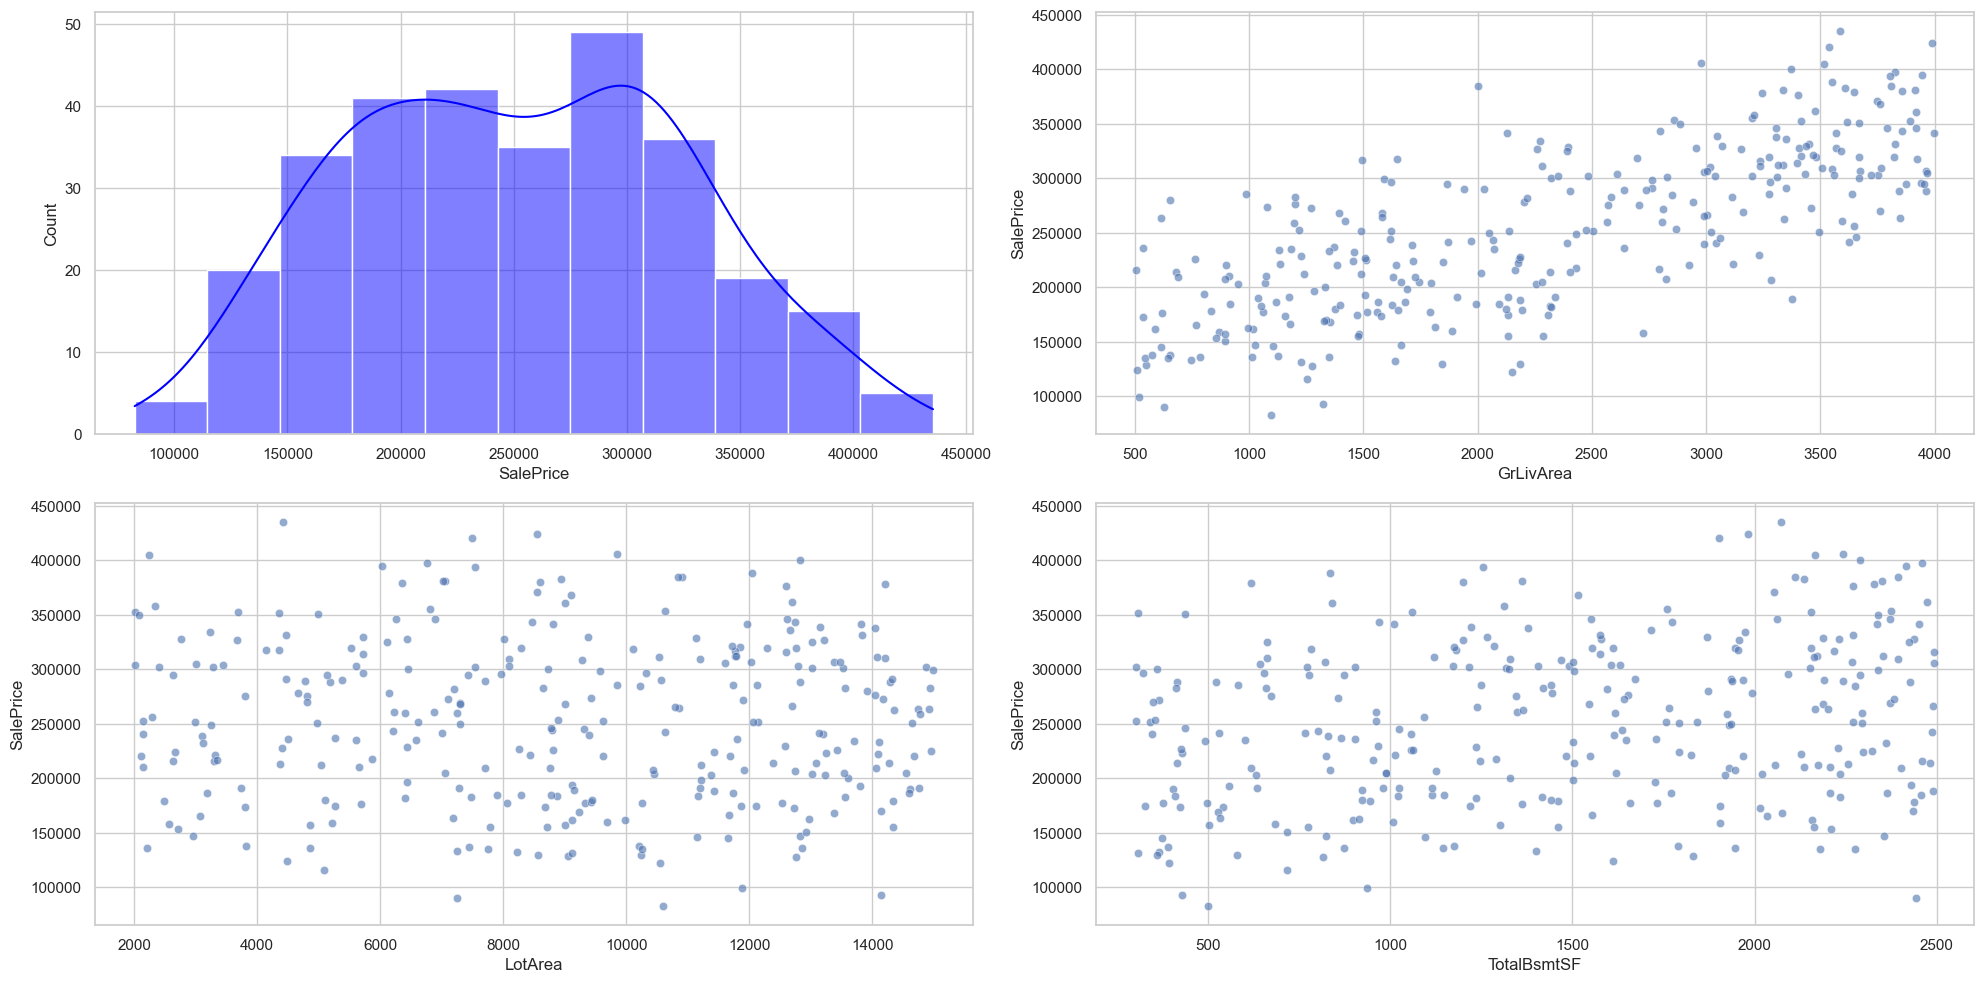

In [484]:
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(2, 2, figsize=(20, 10))

sns.histplot(df['SalePrice'], kde=True, ax=axes[0,0], color='blue')

sns.scatterplot(data=df, x='GrLivArea', y='SalePrice', ax=axes[0,1], alpha=0.6)

sns.scatterplot(data=df, x='LotArea', y='SalePrice', ax=axes[1,0], alpha=0.6)

sns.scatterplot(data=df, x='TotalBsmtSF', y='SalePrice', ax=axes[1,1], alpha=0.6)

plt.tight_layout()
plt.show()

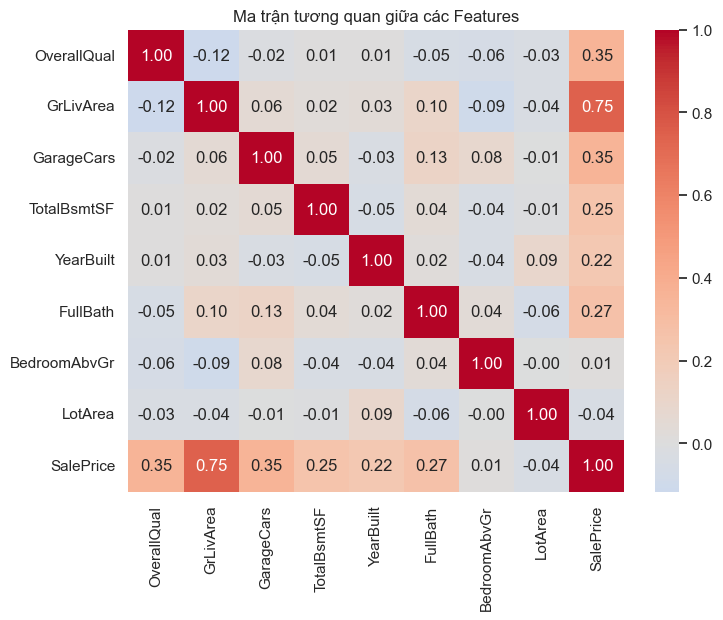

In [485]:
plt.figure(figsize=(8, 6))
corr_matrix = df.corr()
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='coolwarm', center=0)
plt.title("Ma trận tương quan giữa các Features")
plt.show()

### Feature Engineering

In [486]:
df.head()

,OverallQual,GrLivArea,GarageCars,TotalBsmtSF,YearBuilt,FullBath,BedroomAbvGr,LotArea,SalePrice
0,7,1560,0,1658,1969,2,1,8059,177106
1,4,2827,2,1319,2012,3,4,13530,301044
2,8,3920,0,841,2010,1,4,9010,360609
3,5,3044,0,1058,1998,0,4,13207,240556
4,7,801,1,2428,2020,0,1,9117,193656


In [5]:
cur_year = 2026
df["AgeHouse"] = cur_year - df["YearBuilt"]

# Tổng diện tích (sàn + tầng hầm)
df['TotalSF'] = df['GrLivArea'] + df['TotalBsmtSF']

# Tương tác chất lượng * diện tích
df['Qual*Area'] = df['OverallQual'] * df['GrLivArea']

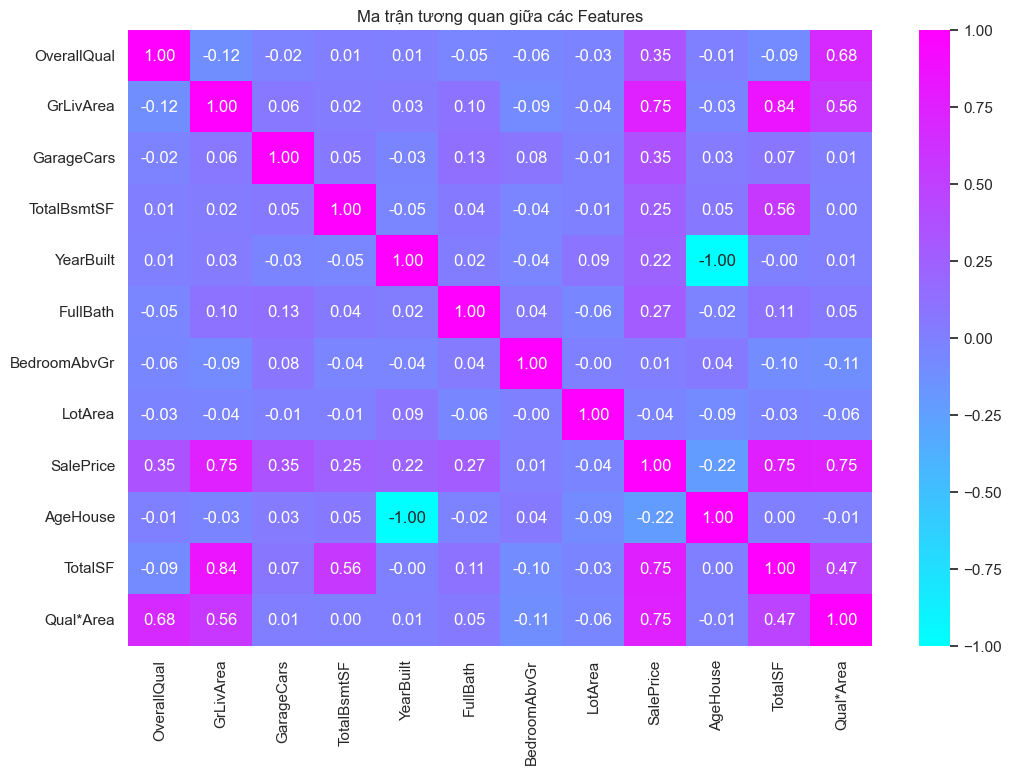

In [488]:
plt.figure(figsize=(12, 8))
corr_matrix = df.corr()
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='cool', center=0)
plt.title("Ma trận tương quan giữa các Features")
plt.show()

### Data Processing

In [489]:
class MyStandardScaler:
    def __init__(self):
        self.mean_ = None
        self.std_ = None
        
    def fit(self, X):
        X_array = np.asarray(X)
        # Tính trung bình và độ lệch chuẩn theo từng cột
        self.mean_ = np.mean(X_array, axis=0)
        self.std_ = np.std(X_array, axis=0)
        # Tránh lỗi khi chia cho 0
        self.std_[self.std_==0] = 1e-9
        return self
        
    def transform(self, X):
        X_array = np.asarray(X)
        # Áp dụng công thức: (X - mean) / std
        return (X_array - self.mean_) / self.std_
         
    def fit_transform(self, X):
        self.fit(X)
        return self.transform(X)

In [6]:
features_cols = ['AgeHouse', 'TotalSF', 'Qual*Area',
                 'GarageCars', 'FullBath']

In [491]:
features_cols_og = ["OverallQual", "GrLivArea", "GarageCars", "TotalBsmtSF", "YearBuilt", "FullBath", "BedroomAbvGr", "LotArea"]

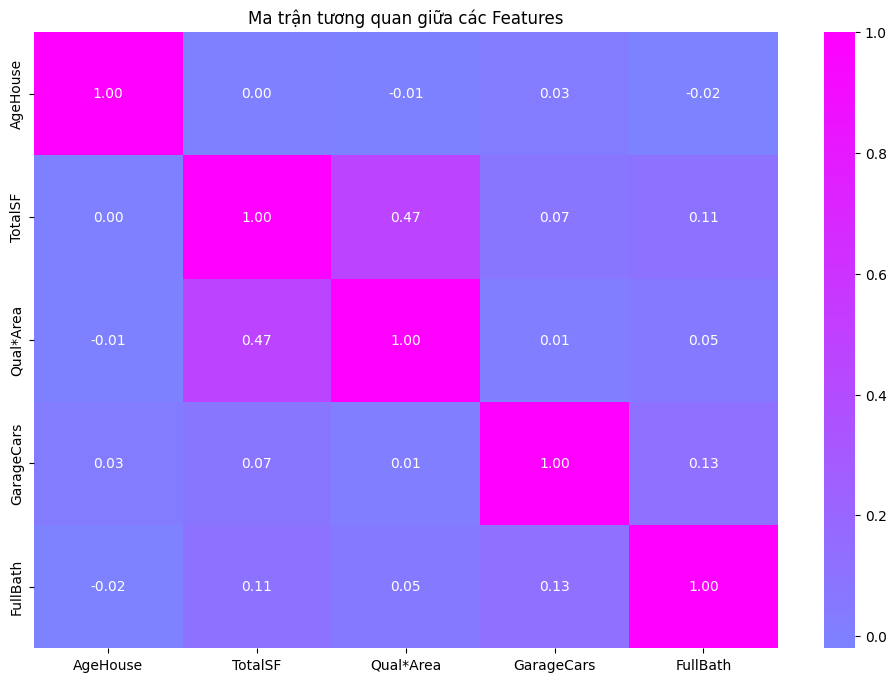

In [7]:
plt.figure(figsize=(12, 8))
corr_matrix = df[features_cols].corr()
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='cool', center=0)
plt.title("Ma trận tương quan giữa các Features")
plt.show()

In [492]:
X = df[features_cols]
y = df['SalePrice']

In [493]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=172)

print(f"Tổng số mẫu: {len(df)}")
print(f"Số mẫu tập Train: {len(X_train)} (~80%)")
print(f"Số mẫu tập Test:  {len(X_test)} (~20%)")


print("Kích thước ma trận Train:", X_train.shape)
print("Kích thước ma trận Test:", X_test.shape)

Tổng số mẫu: 300
Số mẫu tập Train: 240 (~80%)
Số mẫu tập Test:  60 (~20%)
Kích thước ma trận Train: (240, 5)
Kích thước ma trận Test: (60, 5)


In [494]:
col_scaler = [
    "AgeHouse", "TotalSF", 
    "GarageCars", "FullBath", "Qual*Area"
]

col_or_scaler = [
    "OverallQual", "GrLivArea", "GarageCars", 
    "TotalBsmtSF", "YearBuilt", "FullBath", "BedroomAbvGr", "LotArea"
]

scaler = MyStandardScaler()

X_train[col_scaler] = scaler.fit_transform(X_train[col_scaler])
X_test[col_scaler] = scaler.transform(X_test[col_scaler])

In [495]:
X_train.describe().round(2)

,AgeHouse,TotalSF,Qual*Area,GarageCars,FullBath
count,240.00,240.00,240.00,240.00,240.00
mean,-0.00,-0.00,0.00,0.00,0.00
std,1.00,1.00,1.00,1.00,1.00
min,-1.72,-2.23,-1.31,-1.22,-1.35
25%,-0.84,-0.77,-0.82,-1.22,-0.68
50%,0.00,-0.01,-0.22,-0.31,0.44
75%,0.89,0.73,0.57,0.60,0.44
max,1.68,2.25,2.77,1.51,1.34


In [496]:
X_train_tensor = torch.FloatTensor(X_train.values)
X_test_tensor = torch.FloatTensor(X_test.values)

y_train = np.log1p(y_train.values)
y_test = np.log1p(y_test.values)

y_train_tensor = torch.FloatTensor(y_train).view(-1, 1)
y_test_tensor = torch.FloatTensor(y_test).view(-1, 1)

In [497]:
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

batch_size = 32

train_loader = DataLoader(dataset=train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(dataset=test_dataset, batch_size=batch_size, shuffle=False)

### Model Neural Network

In [498]:
import numpy as np

def compute_mse(y, y_pred):
    return np.mean((y-y_pred) ** 2)

def compute_mae(y, y_pred):
    return np.mean(np.abs(y-y_pred))

def compute_mape(y, y_pred):
    return 100 * np.mean(np.abs(y-y_pred) / y)

def compute_r2(y, y_pred):
    ss_res = np.mean((y - y_pred) ** 2)
    ss_tot = np.mean((y - np.mean(y)) ** 2)
        
    return 1 - (ss_res / ss_tot)

def regression_report(y, y_pred):
    mae = compute_mae(y, y_pred)
    mse = compute_mse(y, y_pred)
    rmse = np.sqrt(mse)
    r2 = compute_r2(y, y_pred)
    mape = compute_mape(y, y_pred)

    print("Regression Report")
    print("------------------")
    print(f"MAE  : {mae:.4f}")
    print(f"MSE  : {mse:.4f}")
    print(f"RMSE : {rmse:.4f}")
    print(f"R2   : {r2:.4f}")
    print(f"MAPE : {mape:.4f}")

In [499]:
class HousePriceNN(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 32),
            nn.ReLU(),
            nn.Linear(32, 16),
            nn.ReLU(),
            nn.Linear(16, 8),
            nn.ReLU(),
            nn.Linear(8, 1)
        )
    
    def forward(self, x):
        return self.net(x)

In [505]:
# Khởi tạo mô hình
input_dim = X_train.shape[1] # Số lượng cột đầu vào
model = HousePriceNN(input_dim)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

# Hàm mất mát cho phân loại nhị phân
criterion = nn.MSELoss()   # vì target đã log1p, dùng MSE
optimizer = optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-2)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=40)

# Early stopping parameters
best_val_loss = float('inf')
patience = 150
counter = 0
best_model_state = None

num_epochs = 1000
train_losses = []
val_losses = []

for epoch in range(num_epochs):
    # Training
    model.train()
    train_loss = 0.0
    for Xb, yb in train_loader:
        Xb, yb = Xb.to(device), yb.to(device)
        optimizer.zero_grad()
        pred = model(Xb)
        loss = criterion(pred, yb)
        loss.backward()
        optimizer.step()
        train_loss += loss.item() * Xb.size(0)
    train_loss /= len(train_loader.dataset)
    train_losses.append(train_loss)
    
    # Validation
    model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for Xb, yb in test_loader:
            Xb, yb = Xb.to(device), yb.to(device)
            pred = model(Xb)
            loss = criterion(pred, yb)
            val_loss += loss.item() * Xb.size(0)
    val_loss /= len(test_loader.dataset)
    val_losses.append(val_loss)
    
    # Learning rate scheduling
    scheduler.step(val_loss)
    
    # Early stopping
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        counter = 0
        best_model_state = model.state_dict().copy()
    else:
        counter += 1
        if counter >= patience:
            print(f"Early stopping at epoch {epoch+1}")
            break
    
    if (epoch+1) % 100 == 0:
        print(f"Epoch {epoch+1:3d} | Train Loss: {train_loss:.6f} | Val Loss: {val_loss:.6f} | LR: {optimizer.param_groups[0]['lr']:.5f}")

Epoch 100 | Train Loss: 0.274963 | Val Loss: 0.377522 | LR: 0.00100
Epoch 200 | Train Loss: 0.032395 | Val Loss: 0.096457 | LR: 0.00100
Epoch 300 | Train Loss: 0.017341 | Val Loss: 0.067330 | LR: 0.00100
Epoch 400 | Train Loss: 0.012777 | Val Loss: 0.045983 | LR: 0.00100
Epoch 500 | Train Loss: 0.010752 | Val Loss: 0.029588 | LR: 0.00100
Epoch 600 | Train Loss: 0.009372 | Val Loss: 0.020619 | LR: 0.00100
Epoch 700 | Train Loss: 0.006622 | Val Loss: 0.011837 | LR: 0.00100
Epoch 800 | Train Loss: 0.005886 | Val Loss: 0.007284 | LR: 0.00100
Epoch 900 | Train Loss: 0.006017 | Val Loss: 0.008246 | LR: 0.00050
Early stopping at epoch 976


In [506]:
model.load_state_dict(best_model_state)

<All keys matched successfully>

In [507]:
model.eval()
with torch.no_grad():
    y_pred_log = model(X_test_tensor.to(device)).cpu().numpy()
    y_true_log = y_test_tensor.numpy()
    
# Chuyển ngược từ log1p sang giá gốc
y_pred = np.expm1(y_pred_log)
y_true = np.expm1(y_true_log)

regression_report(y_true, y_pred)

# (Tuỳ chọn) In thử 5 dự đoán đầu tiên
print("\nSo sánh 5 mẫu đầu tiên:")
for i in range(5):
    print(f"Thực tế: {y_true[i][0]:10,.0f} - Dự đoán: {y_pred[i][0]:10,.0f} | Sai số: {abs(y_true[i][0]-y_pred[i][0]):,.0f}")

Regression Report
------------------
MAE  : 14420.4707
MSE  : 351655712.0000
RMSE : 18752.4863
R2   : 0.9407
MAPE : 6.0788

So sánh 5 mẫu đầu tiên:
Thực tế:    181,535 - Dự đoán:    205,767 | Sai số: 24,232
Thực tế:    328,244 - Dự đoán:    346,074 | Sai số: 17,830
Thực tế:    341,755 - Dự đoán:    340,431 | Sai số: 1,324
Thực tế:    253,397 - Dự đoán:    291,999 | Sai số: 38,602
Thực tế:    173,807 - Dự đoán:    168,432 | Sai số: 5,375


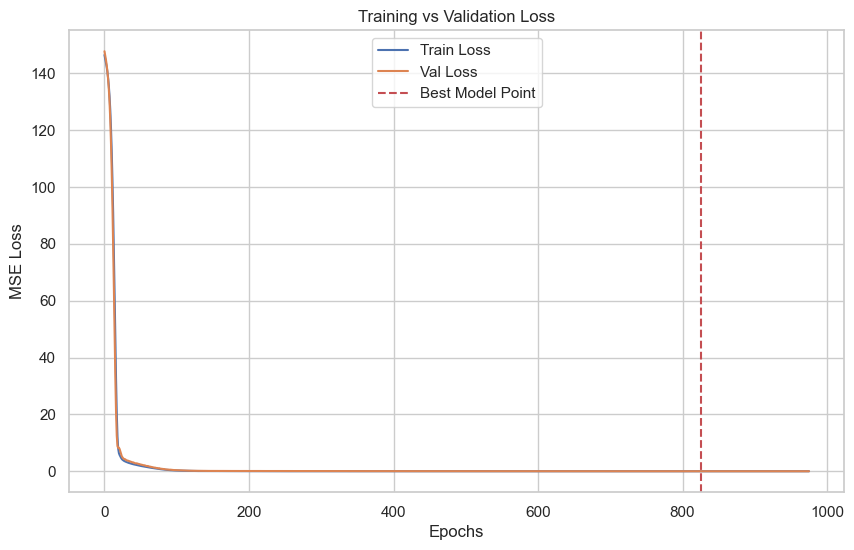

In [508]:
plt.figure(figsize=(10, 6))
sns.lineplot(label='Train Loss', data=train_losses)
sns.lineplot(label='Val Loss', data=val_losses)
plt.axvline(x=len(train_losses)-patience, color='r', linestyle='--', label='Best Model Point')
plt.title('Training vs Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('MSE Loss')
plt.legend()
plt.show()

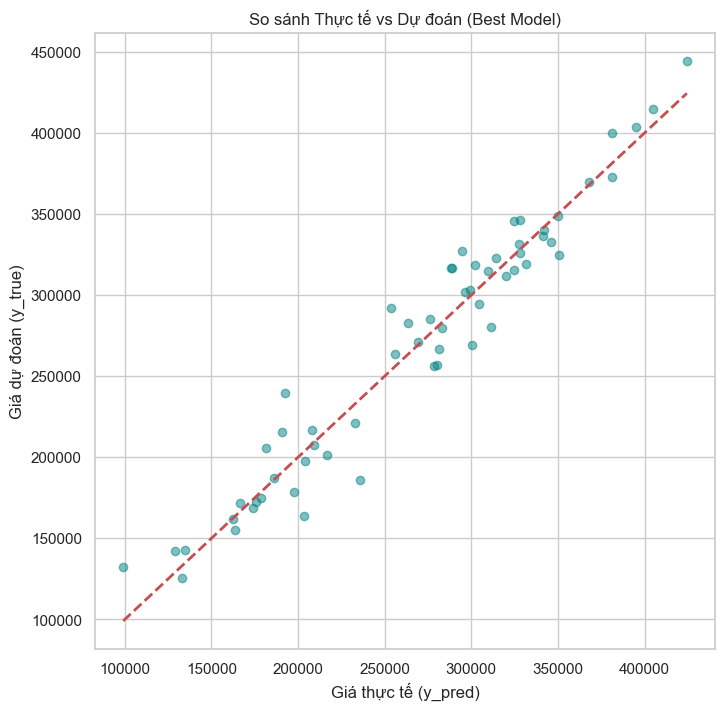

In [509]:
plt.figure(figsize=(8, 8))
plt.scatter(y_true, y_pred, alpha=0.5, color='teal')
plt.plot([y_true.min(), y_true.max()], [y_true.min(), y_true.max()], 'r--', lw=2)
plt.xlabel('Giá thực tế (y_pred)')
plt.ylabel('Giá dự đoán (y_true)')
plt.title('So sánh Thực tế vs Dự đoán (Best Model)')
plt.show()